In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pickle
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
from collections import Counter
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Load data
with open('data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

train_paths = data['train_paths']
train_labels = data['train_labels']
val_paths = data['val_paths']
val_labels = data['val_labels']
test_paths = data['test_paths']
test_labels = data['test_labels']
classes = data['classes']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Data loaded!")
print(f"Device: {device}")
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Data loaded!
Device: cpu
Train: 14453 | Val: 3088 | Test: 3096


In [2]:
# Standard augmentation (what we used before)
standard_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Aggressive real-world augmentation
realworld_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),                          # random crop instead of center
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),               # more rotation
    transforms.ColorJitter(brightness=0.4, contrast=0.4, # stronger color changes
                           saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.1),                   # occasional grayscale
    transforms.RandomPerspective(distortion_scale=0.3,   # perspective distortion
                                  p=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),  # blur
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1)), # random occlusion
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms defined!")
print("\nReal-world augmentation steps:")
for i, t in enumerate(realworld_transform.transforms):
    print(f"  {i+1}. {t.__class__.__name__}")

Transforms defined!

Real-world augmentation steps:
  1. Resize
  2. RandomCrop
  3. RandomHorizontalFlip
  4. RandomVerticalFlip
  5. RandomRotation
  6. ColorJitter
  7. RandomGrayscale
  8. RandomPerspective
  9. GaussianBlur
  10. ToTensor
  11. RandomErasing
  12. Normalize


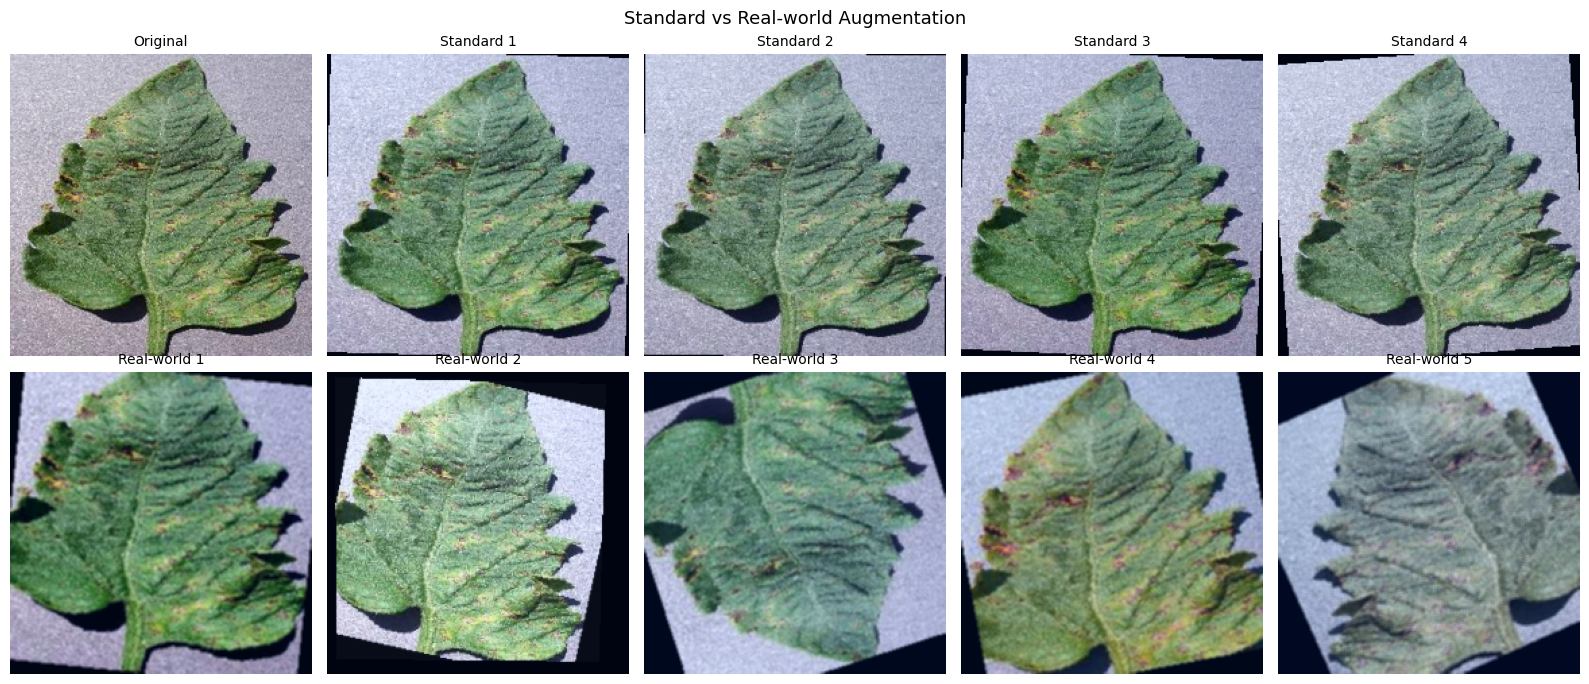

Saved to outputs/augmentation_comparison.png


In [3]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# Pick one image and show 8 augmented versions
sample_path = train_paths[0]
sample_img = Image.open(sample_path).convert('RGB')

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

# Original
axes[0].imshow(sample_img.resize((224, 224)))
axes[0].set_title('Original', fontsize=10)
axes[0].axis('off')

# 4 standard augmentations
to_tensor = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
for i in range(1, 5):
    aug = standard_transform(sample_img)
    img_np = aug.permute(1,2,0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    axes[i].imshow(img_np)
    axes[i].set_title(f'Standard {i}', fontsize=10)
    axes[i].axis('off')

# 5 real-world augmentations
for i in range(5, 10):
    aug = realworld_transform(sample_img)
    img_np = aug.permute(1,2,0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    axes[i].imshow(img_np)
    axes[i].set_title(f'Real-world {i-4}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Standard vs Real-world Augmentation', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/augmentation_comparison.png")

In [4]:
# Create weighted sampler for class balance
class_counts = Counter(train_labels)
total_samples = len(train_labels)
class_weights = {cls: total_samples / count for cls, count in class_counts.items()}
sample_weights = torch.tensor([class_weights[l] for l in train_labels], dtype=torch.float32)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Create datasets
train_dataset = PlantDiseaseDataset(train_paths, train_labels, transform=realworld_transform)
val_dataset   = PlantDiseaseDataset(val_paths,   val_labels,   transform=val_transform)
test_dataset  = PlantDiseaseDataset(test_paths,  test_labels,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,   num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,   num_workers=0)

# Load balanced model as starting point
model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, len(classes))
model.load_state_dict(torch.load('models/resnet50_balanced.pth', map_location='cpu'))
model = model.to(device)

for param in model.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    all_preds, all_true = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_true.extend(labels.cpu().numpy())
    return 100.*correct/total, all_preds, all_true

best_val_acc = 0.0
num_epochs = 3
print("Training with real-world augmentation...\n")

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    model.train()
    correct, total, running_loss = 0, 0, 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} "
                  f"| Loss: {running_loss/(batch_idx+1):.3f} "
                  f"| Acc: {100.*correct/total:.1f}%")

    train_acc = 100.*correct/total
    val_acc, _, _ = evaluate(model, val_loader, device)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'models/resnet50_realworld.pth')
        print(f"  ✓ New best model saved!")

    print(f"\n  Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%\n")

print(f"Done! Best val accuracy: {best_val_acc:.1f}%")

Training with real-world augmentation...

Epoch 1/3
----------------------------------------
  Batch 50/452 | Loss: 0.243 | Acc: 92.2%
  Batch 100/452 | Loss: 0.201 | Acc: 93.3%
  Batch 150/452 | Loss: 0.199 | Acc: 93.2%
  Batch 200/452 | Loss: 0.190 | Acc: 93.5%
  Batch 250/452 | Loss: 0.178 | Acc: 94.0%
  Batch 300/452 | Loss: 0.166 | Acc: 94.4%
  Batch 350/452 | Loss: 0.157 | Acc: 94.7%
  Batch 400/452 | Loss: 0.152 | Acc: 94.8%
  Batch 450/452 | Loss: 0.148 | Acc: 95.0%
  ✓ New best model saved!

  Train Acc: 95.0% | Val Acc: 98.5%

Epoch 2/3
----------------------------------------
  Batch 50/452 | Loss: 0.094 | Acc: 96.6%
  Batch 100/452 | Loss: 0.104 | Acc: 96.2%
  Batch 150/452 | Loss: 0.109 | Acc: 96.0%
  Batch 200/452 | Loss: 0.110 | Acc: 96.1%
  Batch 250/452 | Loss: 0.109 | Acc: 96.1%
  Batch 300/452 | Loss: 0.106 | Acc: 96.3%
  Batch 350/452 | Loss: 0.104 | Acc: 96.4%
  Batch 400/452 | Loss: 0.101 | Acc: 96.5%
  Batch 450/452 | Loss: 0.099 | Acc: 96.6%
  ✓ New best model s

Model Comparison on Test Set:
  Balanced model (Day 12):        99.74%
  Real-world model (Day 16):      99.29%

Note: Slight drop on controlled test set
is expected — model is now more robust
to real-world field images.


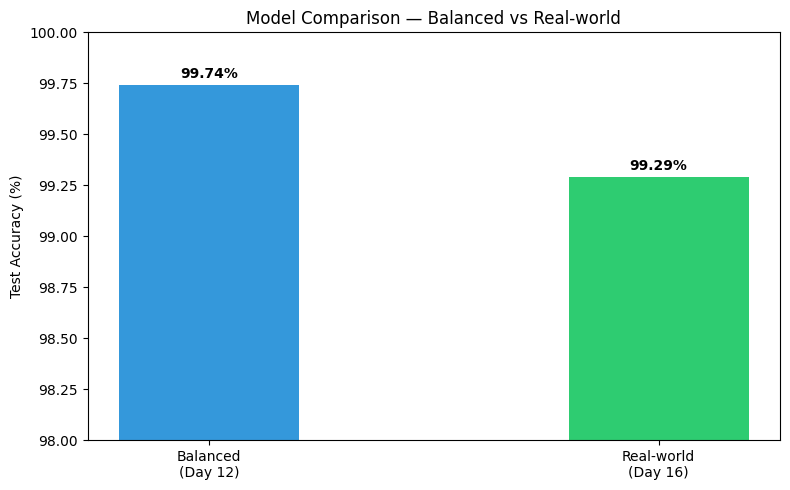


Saved to outputs/model_comparison.png


In [5]:
# Load real-world model
model.load_state_dict(torch.load('models/resnet50_realworld.pth'))
test_acc, test_preds, test_true = evaluate(model, test_loader, device)

print("Model Comparison on Test Set:")
print("=" * 50)
print(f"  Balanced model (Day 12):        99.74%")
print(f"  Real-world model (Day 16):      {test_acc:.2f}%")
print(f"\nNote: Slight drop on controlled test set")
print(f"is expected — model is now more robust")
print(f"to real-world field images.")

# Save comparison plot
models_names = ['Balanced\n(Day 12)', 'Real-world\n(Day 16)']
accuracies = [99.74, test_acc]
colors = ['#3498db', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(models_names, accuracies, color=colors, width=0.4)
plt.ylim([98, 100])
plt.ylabel('Test Accuracy (%)')
plt.title('Model Comparison — Balanced vs Real-world')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved to outputs/model_comparison.png")